<a href="https://colab.research.google.com/github/ByvatovS/ML_Task/blob/main/Energy_Consumption_Dataset_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!unzip EnergyCD.zip

Archive:  EnergyCD.zip
  inflating: test_energy_data.csv    
  inflating: train_energy_data.csv   


О Датасете:


*   Building Type - Категориальный признак, представляющий тип здания.
*   Square Footage - Числовой признак, представляющий общую площадь здания.
*   Number of Occupants - Числовой признак, указывающий на количество людей, проживающих в здании.
*   Appliances Used - Числовой признак, представляющий количество бытовой техники, используемой в здании.
*   Average Temperature - Числовой показатель, представляющий среднюю температуру здания или климатической зоны (в градусах Цельсия).
*   Day of Week - Категориальный признак, показывающий, соответствует ли точка данных буднему дню или выходному.
*   Energy Consumption - Числовая целевая переменная, представляющая потребление энергии зданием в кВтч (киловатт-часах). Это значение.






In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import StandardScaler , LabelEncoder


In [5]:
train = pd.read_csv('train_energy_data.csv')
test = pd.read_csv('test_energy_data.csv')

In [6]:
train.head()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


In [8]:
train.shape

(1000, 7)

In [10]:
train.duplicated().sum()

0

In [12]:
train.dtypes

,0
Building Type,object
Square Footage,int64
Number of Occupants,int64
Appliances Used,int64
Average Temperature,float64
Day of Week,object
Energy Consumption,float64


In [19]:
num_cols = ['Square Footage' , 'Number of Occupants', 'Appliances Used' , 'Average Temperature', 'Energy Consumption']
cat_cols = ['Building Type' , 'Day of Week']

In [21]:
train['Building Type'].value_counts()

,count
Building Type,
Residential,347
Commercial,336
Industrial,317


In [22]:
train['Day of Week'].value_counts()

,count
Day of Week,
Weekday,507
Weekend,493


In [15]:
train.isna().sum()

,0
Building Type,0
Square Footage,0
Number of Occupants,0
Appliances Used,0
Average Temperature,0
Day of Week,0
Energy Consumption,0


In [17]:
train.describe()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
count,1000.000,1000.000000,1000.000000,1000.000000,1000.000000
mean,25462.388,48.372000,25.606000,22.611390,4166.252570
std,14294.554,29.061972,14.105166,7.139943,933.313064
min,560.000,1.000000,1.000000,10.050000,1683.950000
25%,13169.750,22.000000,13.000000,16.475000,3509.482500
50%,25477.000,47.000000,26.000000,22.815000,4175.730000
75%,37446.250,73.250000,38.000000,28.850000,4863.850000
max,49997.000,99.000000,49.000000,34.990000,6530.600000


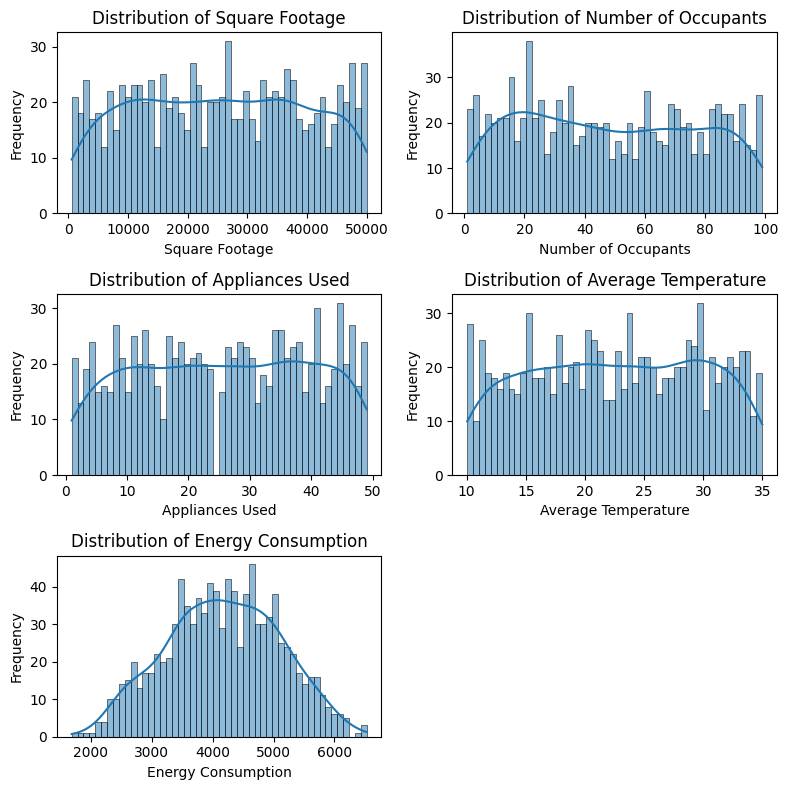

In [40]:
fig , axs = plt.subplots(3 ,2, figsize = (8 , 8))
axs = axs.flatten()
for ind , col in enumerate(num_cols):
  sns.histplot(train[col] , ax = axs[ind] , bins= 50 , kde = True)
  axs[ind].set_xlabel(col)
  axs[ind].set_ylabel("Frequency")
  axs[ind].set_title(f'Distribution of {col}')

fig.delaxes(axs[5])

plt.tight_layout()
plt.show()

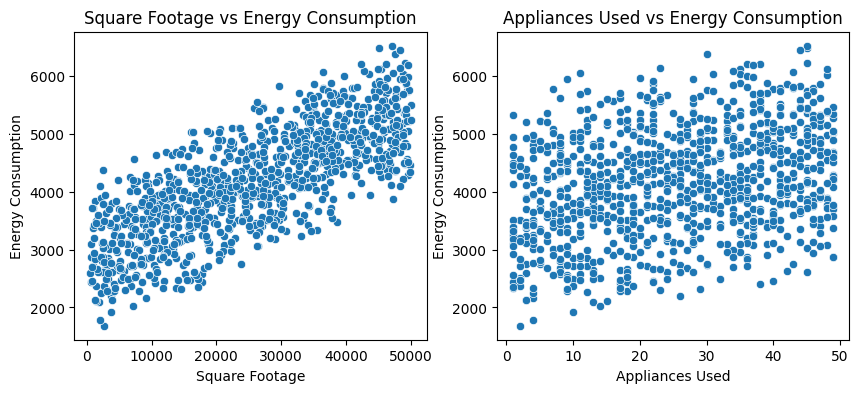

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.scatterplot(x=train['Square Footage'], y=train['Energy Consumption'], ax=axes[0])
axes[0].set_title("Square Footage vs Energy Consumption")

sns.scatterplot(x=train['Appliances Used'], y=train['Energy Consumption'], ax=axes[1])
axes[1].set_title("Appliances Used vs Energy Consumption")

plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


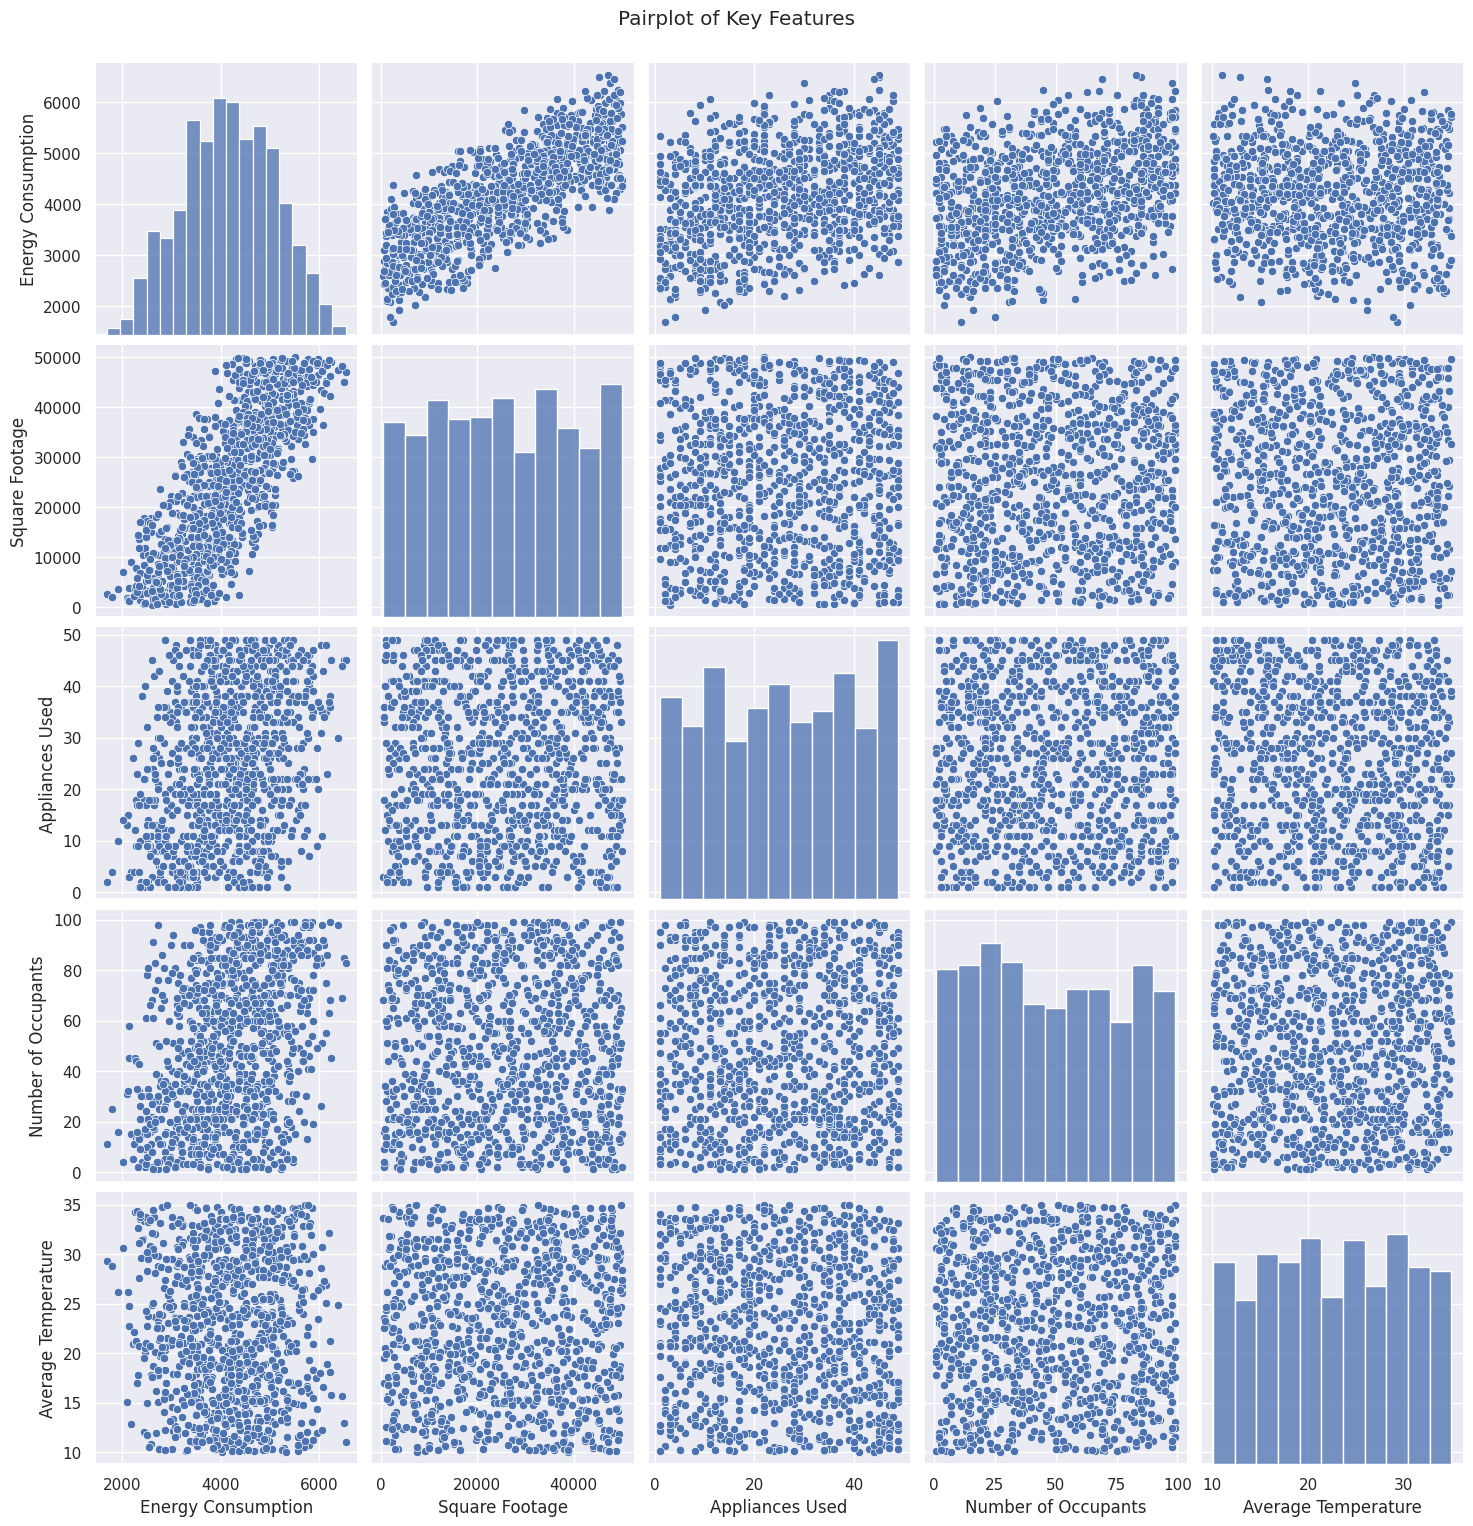

In [43]:
sns.set()
features = ["Energy Consumption", "Square Footage", "Appliances Used", "Number of Occupants", "Average Temperature"]
sns.pairplot(train[features], size = 3)
plt.suptitle("Pairplot of Key Features", y=1.02)
plt.show()

In [45]:
encoder = LabelEncoder()
train_ = train.copy()
train_['Building Type'] = encoder.fit_transform(train_[['Building Type']])
train_['Day of Week'] = encoder.fit_transform(train_['Day of Week'])


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


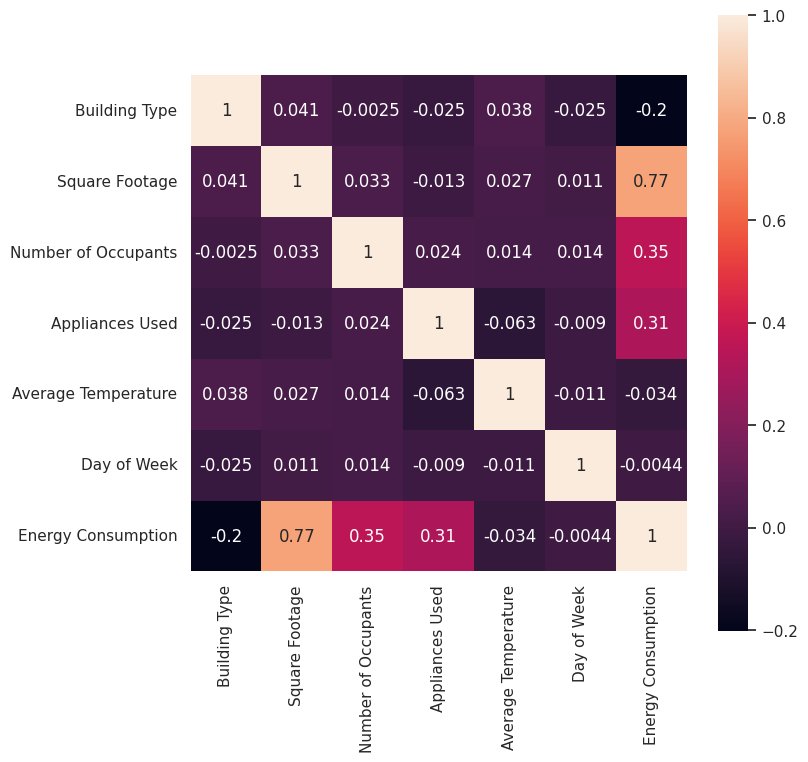

In [49]:
matrix_corr = train_.corr()
fig = plt.figure(figsize= (8,8))
sns.heatmap(matrix_corr , square = True , annot= True)
plt.show()

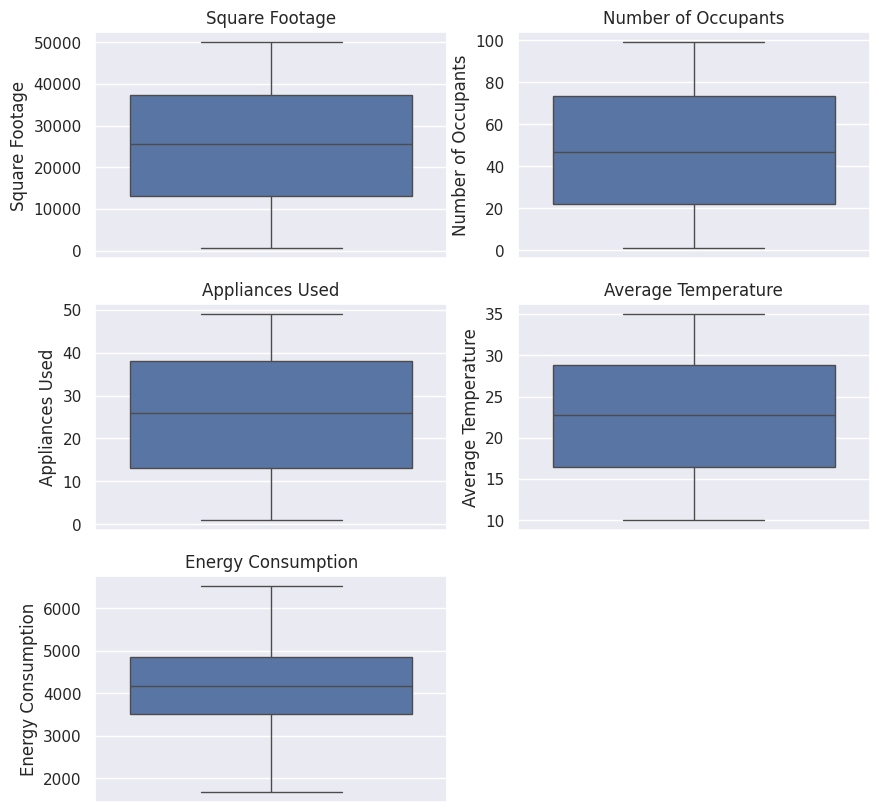

In [53]:
fig , axs = plt.subplots(3 , 2 , figsize = (10 , 10))
axs = axs.flatten()
for ind , col in enumerate(num_cols):
  sns.boxplot(train[col] , ax= axs[ind])
  axs[ind].set_title(col)

fig.delaxes(axs[5])
plt.show()

In [56]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 6.4 MB/s eta 0:00:00


In [89]:
from catboost import Pool , cv , CatBoostRegressor
cat = CatBoostRegressor()

params ={
    "iterations": np.arange(100 , 500 , 50),
    "learning_rate": np.arange(0.01 , 0.5 , 0.05),
    "l2_leaf_reg": np.arange(1 ,5 ,0.5),
    "depth": np.arange(2 , 5)
}

X_train = train.drop(['Energy Consumption'] , axis = 1)
y_train = train['Energy Consumption']
cv_data = Pool(data = X_train , label = y_train , cat_features = cat_cols)

grid_search_result = cat.grid_search(params, X=cv_data , cv = 5 , verbose= False)

In [86]:
best_params = grid_search_result['params']
best_params['loss_function'] = "RMSE"
# best_params['verbose'] = False
best_params['eval_metric']='RMSE'
print(f'Лучшие параметры: {best_params}')

Лучшие параметры: {'depth': 2, 'learning_rate': 0.46, 'l2_leaf_reg': 1.5, 'iterations': 450, 'loss_function': 'RMSE', 'eval_metric': 'RMSE'}


In [90]:
best_params

{'depth': 2,
 'learning_rate': 0.46,
 'l2_leaf_reg': 1.5,
 'iterations': 450,
 'loss_function': 'RMSE',
 'eval_metric': 'RMSE'}

In [91]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error


best_loss = -1
best_model = None
new_train_pool = None


kf = KFold(n_splits = 5)
for train_ind , test_ind in kf.split(X_train):
  X_tr , X_ts = X_train.iloc[train_ind] , X_train.iloc[test_ind]
  y_tr , y_ts = y_train.iloc[train_ind] , y_train.iloc[test_ind]

  train_pool = Pool(data = X_tr, label = y_tr , cat_features = cat_cols)
  test_pool = Pool(data= X_ts , label = y_ts , cat_features= cat_cols )

  model = CatBoostRegressor(**best_params)
  model.fit(train_pool, eval_set=test_pool, plot=True)

  metrics = model.eval_metrics(test_pool, ['RMSE'])
  test_loss = metrics['RMSE'][-1]

  if (best_loss == -1) or (best_loss > test_loss):
    best_loss = test_loss
    best_model = model
    new_train_pool = test_pool

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 730.8499242	test: 790.6018410	best: 790.6018410 (0)	total: 868us	remaining: 390ms
1:	learn: 606.0669053	test: 659.9332849	best: 659.9332849 (1)	total: 5.14ms	remaining: 1.15s
2:	learn: 510.9570333	test: 543.5352396	best: 543.5352396 (2)	total: 5.83ms	remaining: 869ms
3:	learn: 440.6254430	test: 471.5984170	best: 471.5984170 (3)	total: 6.37ms	remaining: 710ms
4:	learn: 379.8060577	test: 395.2493566	best: 395.2493566 (4)	total: 9.87ms	remaining: 878ms
5:	learn: 329.2571550	test: 325.6053626	best: 325.6053626 (5)	total: 10.4ms	remaining: 769ms
6:	learn: 293.1880564	test: 276.3948555	best: 276.3948555 (6)	total: 10.9ms	remaining: 688ms
7:	learn: 269.7399713	test: 254.7787136	best: 254.7787136 (7)	total: 11.4ms	remaining: 632ms
8:	learn: 245.2520659	test: 231.4634905	best: 231.4634905 (8)	total: 12ms	remaining: 587ms
9:	learn: 225.2416777	test: 208.5087346	best: 208.5087346 (9)	total: 12.4ms	remaining: 547ms
10:	learn: 216.4893234	test: 192.7592855	best: 192.7592855 (10)	total: 12

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 737.2019015	test: 738.6257415	best: 738.6257415 (0)	total: 670us	remaining: 301ms
1:	learn: 630.2625531	test: 661.0736796	best: 661.0736796 (1)	total: 1.82ms	remaining: 408ms
2:	learn: 528.0415753	test: 565.3748550	best: 565.3748550 (2)	total: 3.1ms	remaining: 463ms
3:	learn: 435.1897249	test: 470.7333688	best: 470.7333688 (3)	total: 3.57ms	remaining: 398ms
4:	learn: 378.5523307	test: 409.9992190	best: 409.9992190 (4)	total: 4.01ms	remaining: 357ms
5:	learn: 318.4483133	test: 339.6311700	best: 339.6311700 (5)	total: 4.76ms	remaining: 352ms
6:	learn: 290.5944582	test: 298.9611072	best: 298.9611072 (6)	total: 5.25ms	remaining: 333ms
7:	learn: 260.7105418	test: 267.0596782	best: 267.0596782 (7)	total: 6.45ms	remaining: 356ms
8:	learn: 237.0655733	test: 238.2133686	best: 238.2133686 (8)	total: 7.07ms	remaining: 346ms
9:	learn: 217.9226654	test: 218.9697920	best: 218.9697920 (9)	total: 7.65ms	remaining: 337ms
10:	learn: 197.8756158	test: 193.0140202	best: 193.0140202 (10)	total: 8

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 752.1751003	test: 750.6276323	best: 750.6276323 (0)	total: 596us	remaining: 268ms
1:	learn: 638.8559433	test: 633.7712108	best: 633.7712108 (1)	total: 2.54ms	remaining: 569ms
2:	learn: 522.8215256	test: 530.7973693	best: 530.7973693 (2)	total: 3.07ms	remaining: 457ms
3:	learn: 418.6978209	test: 427.6709482	best: 427.6709482 (3)	total: 3.55ms	remaining: 396ms
4:	learn: 384.7767112	test: 380.2744110	best: 380.2744110 (4)	total: 4.03ms	remaining: 359ms
5:	learn: 350.6092228	test: 354.6814229	best: 354.6814229 (5)	total: 4.66ms	remaining: 345ms
6:	learn: 306.0335934	test: 300.4157676	best: 300.4157676 (6)	total: 6.06ms	remaining: 383ms
7:	learn: 269.8139336	test: 247.2578003	best: 247.2578003 (7)	total: 6.5ms	remaining: 359ms
8:	learn: 242.5699118	test: 214.3686837	best: 214.3686837 (8)	total: 6.95ms	remaining: 341ms
9:	learn: 228.4601879	test: 200.3760944	best: 200.3760944 (9)	total: 7.44ms	remaining: 327ms
10:	learn: 209.3009072	test: 191.7869884	best: 191.7869884 (10)	total: 8

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 734.1347512	test: 712.8627711	best: 712.8627711 (0)	total: 3.77ms	remaining: 1.69s
1:	learn: 627.8701476	test: 619.5969076	best: 619.5969076 (1)	total: 4.39ms	remaining: 984ms
2:	learn: 571.3965977	test: 559.8349562	best: 559.8349562 (2)	total: 7.14ms	remaining: 1.06s
3:	learn: 456.5431011	test: 448.8516871	best: 448.8516871 (3)	total: 8.37ms	remaining: 933ms
4:	learn: 389.0671460	test: 371.6242076	best: 371.6242076 (4)	total: 9.39ms	remaining: 836ms
5:	learn: 340.2625268	test: 325.4103049	best: 325.4103049 (5)	total: 9.86ms	remaining: 729ms
6:	learn: 297.7867657	test: 283.4778596	best: 283.4778596 (6)	total: 10.3ms	remaining: 651ms
7:	learn: 263.3872669	test: 254.8116431	best: 254.8116431 (7)	total: 10.8ms	remaining: 594ms
8:	learn: 245.9971481	test: 230.3896126	best: 230.3896126 (8)	total: 11.2ms	remaining: 549ms
9:	learn: 220.5034678	test: 204.9728463	best: 204.9728463 (9)	total: 11.7ms	remaining: 516ms
10:	learn: 209.0002860	test: 192.7816614	best: 192.7816614 (10)	total:

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 741.4887941	test: 751.2884530	best: 751.2884530 (0)	total: 772us	remaining: 347ms
1:	learn: 616.6356778	test: 616.3610814	best: 616.3610814 (1)	total: 1.44ms	remaining: 322ms
2:	learn: 522.4254333	test: 524.8920435	best: 524.8920435 (2)	total: 5.14ms	remaining: 766ms
3:	learn: 410.3120433	test: 407.0776474	best: 407.0776474 (3)	total: 6.07ms	remaining: 677ms
4:	learn: 356.2260615	test: 340.5023105	best: 340.5023105 (4)	total: 6.67ms	remaining: 594ms
5:	learn: 307.7325094	test: 282.1631170	best: 282.1631170 (5)	total: 7.24ms	remaining: 536ms
6:	learn: 274.1572090	test: 254.5352197	best: 254.5352197 (6)	total: 7.72ms	remaining: 489ms
7:	learn: 246.6674129	test: 225.3595736	best: 225.3595736 (7)	total: 8.19ms	remaining: 452ms
8:	learn: 222.4227372	test: 196.6646614	best: 196.6646614 (8)	total: 8.62ms	remaining: 422ms
9:	learn: 206.0904012	test: 179.4833573	best: 179.4833573 (9)	total: 11.2ms	remaining: 492ms
10:	learn: 192.9946539	test: 164.8280171	best: 164.8280171 (10)	total: 

In [92]:
print(f"Лучший лосс: {best_loss}")

Лучший лосс: 34.72623098313705


In [94]:
X_test = test.drop(['Energy Consumption'] , axis=1)
y_test = test['Energy Consumption']
final_test_pool = Pool(data = X_test , label = y_test ,cat_features= cat_cols )

In [104]:
# Предсказания на тестовой выборке
predictions = best_model.predict(final_test_pool)

# Вычисление loss (например, RMSE)
loss = mean_squared_error(np.array(y_test), predictions)
print("Loss на тестовой выборке (RMSE):", np.sqrt(loss))

Loss на тестовой выборке (RMSE): 34.20023511183205


In [105]:
final_model = CatBoostRegressor(**best_params)

history = final_model.fit(new_train_pool, eval_set= test_pool,  init_model=best_model)
metrics = model.eval_metrics(test_pool, ['RMSE'])
test_loss = metrics['RMSE'][-1]
print("Loss на тестовой выборке (RMSE):", test_loss)

0:	learn: 34.0048213	test: 34.0048213	best: 34.0048213 (0)	total: 535us	remaining: 240ms
1:	learn: 32.7614977	test: 32.7614977	best: 32.7614977 (1)	total: 1.21ms	remaining: 270ms
2:	learn: 32.5315776	test: 32.5315776	best: 32.5315776 (2)	total: 1.54ms	remaining: 230ms
3:	learn: 32.0038321	test: 32.0038321	best: 32.0038321 (3)	total: 1.89ms	remaining: 211ms
4:	learn: 31.6127739	test: 31.6127739	best: 31.6127739 (4)	total: 2.22ms	remaining: 197ms
5:	learn: 31.4941455	test: 31.5008639	best: 31.5008639 (5)	total: 2.56ms	remaining: 190ms
6:	learn: 31.4555352	test: 31.5047623	best: 31.5008639 (5)	total: 2.86ms	remaining: 181ms
7:	learn: 30.7015735	test: 30.7519400	best: 30.7519400 (7)	total: 3.16ms	remaining: 174ms
8:	learn: 30.3886506	test: 30.4345552	best: 30.4345552 (8)	total: 3.48ms	remaining: 170ms
9:	learn: 30.2285124	test: 30.2703441	best: 30.2703441 (9)	total: 3.77ms	remaining: 166ms
10:	learn: 30.0730019	test: 30.0976254	best: 30.0976254 (10)	total: 4.04ms	remaining: 161ms
11:	learn

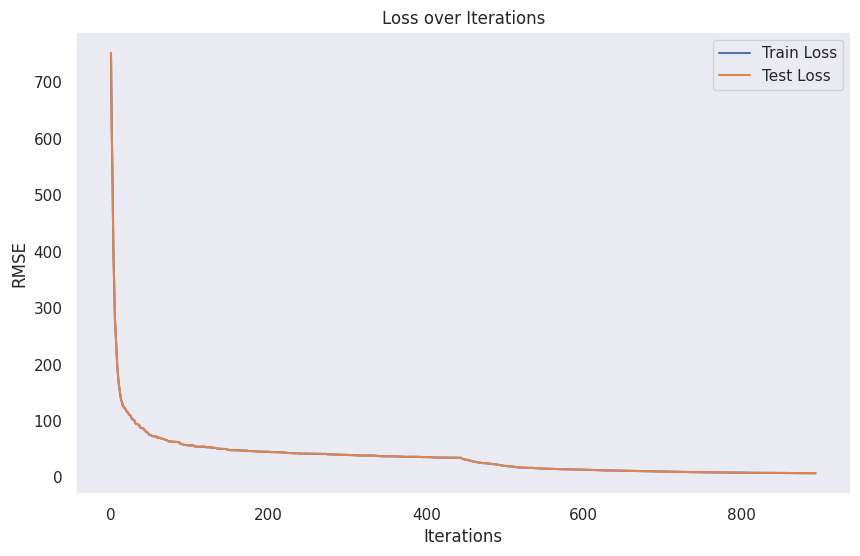

In [110]:
train_loss = final_model.eval_metrics(new_train_pool, ['RMSE'])['RMSE']
test_loss =  final_model.eval_metrics(test_pool, ['RMSE'])['RMSE']

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Train Loss')
plt.plot(test_loss, label='Test Loss')
plt.xlabel('Iterations')
plt.ylabel('RMSE')
plt.title('Loss over Iterations')
plt.legend()
plt.grid()
plt.show()

In [115]:
from sklearn.metrics import r2_score

# Предсказания модели
predictions = best_model.predict(final_test_pool)

# Вычисление R²
r2 = r2_score(y_test, predictions)
print("Коэффициент детерминации (R²):", r2)

Коэффициент детерминации (R²): 0.9982955193998019


In [113]:
from sklearn.metrics import r2_score

# Предсказания модели
predictions = final_model.predict(final_test_pool)

# Вычисление R²
r2 = r2_score(y_test, predictions)
print("Коэффициент детерминации (R²):", r2)

Коэффициент детерминации (R²): 0.9980853684775345


In [117]:
best_model.save_model('/content/catboost_model.cbm')